In [1]:
import numpy as np

from pybotics.geometry import vector_2_matrix
from pybotics.predefined_models import ur10
from pybotics.robot import Robot
from pybotics.tool import Tool


def main() -> None:
    
    robot = Robot.from_parameters(ur10())

    tool = Tool()
    tool.position = np.array([1, 2, 3])
    robot.tool = tool

    world_frame = vector_2_matrix(np.array([100, 200, 300, 0, 0, 0]))
    robot.world_frame = world_frame

    print(f"Robot: {robot}")
    print(f"Kinematic Chain: {robot.kinematic_chain}")


if __name__ == "__main__":
    main()

Robot: Robot(kinematic_chain=MDHKinematicChain(_links=[RevoluteMDHLink(alpha=0.0, a=0.0, theta=0.0, d=118.0), RevoluteMDHLink(alpha=1.5707963267948966, a=0.0, theta=3.141592653589793, d=0.0), RevoluteMDHLink(alpha=0.0, a=612.7, theta=0.0, d=0.0), RevoluteMDHLink(alpha=0.0, a=571.6, theta=0.0, d=163.9), RevoluteMDHLink(alpha=-1.5707963267948966, a=0.0, theta=0.0, d=115.7), RevoluteMDHLink(alpha=1.5707963267948966, a=0.0, theta=3.141592653589793, d=92.2)]), tool=Tool(matrix=array([[1., 0., 0., 1.],
       [0., 1., 0., 2.],
       [0., 0., 1., 3.],
       [0., 0., 0., 1.]]), mass=0, cg=array([0., 0., 0.])), world_frame=array([[  1.,   0.,   0., 100.],
       [  0.,   1.,   0., 200.],
       [  0.,   0.,   1., 300.],
       [  0.,   0.,   0.,   1.]]), random_state=RandomState(MT19937) at 0x74D1E96D9A40, home_position=array([0., 0., 0., 0., 0., 0.]), _joints=array([0., 0., 0., 0., 0., 0.]), _joint_limits=array([[-3.14159265, -3.14159265, -3.14159265, -3.14159265, -3.14159265,
        -3.141

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_poses(p):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xs=p[:, 0, -1], ys=p[:, 1, -1], zs=p[:, 2, -1], marker='o')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_xlim(600, 700)
    ax.set_ylim(-160, -140)
    ax.set_zlim(750, 850)
def compute_deviation(p):
    # compute deviation at joint-space midpoint
    p1 = p[0, :-1, -1]
    p2 = p[1, :-1, -1]
    p3 = p[2, :-1, -1]

    deviation = np.linalg.norm(np.cross(p2 - p1,
                                        p1 - p3)) / np.linalg.norm(p2 - p1)

    print(f'Deviation: {deviation:.5f}mm')
    plt.locator_params(nbins=4)
    plt.tight_layout()


In [4]:
def compute_deviation(p):
    # compute deviation at joint-space midpoint
    p1 = p[0, :-1, -1]
    p2 = p[1, :-1, -1]
    p3 = p[2, :-1, -1]

    deviation = np.linalg.norm(np.cross(p2 - p1,
                                        p1 - p3)) / np.linalg.norm(p2 - p1)

    print(f'Deviation: {deviation:.5f}mm')

In [5]:
from pybotics.predefined_models import ur10
from pybotics.robot import Robot

robot = Robot.from_parameters(ur10())



In [6]:
import numpy as np
from pybotics.geometry import vector_2_matrix

poses = np.array([
    vector_2_matrix([600, -150, 800,
                     np.deg2rad(-90), 0,
                     np.deg2rad(-90)]),
    vector_2_matrix([700, -150, 800,
                     np.deg2rad(-90), 0,
                     np.deg2rad(-90)])
])

start_end_joints = [robot.ik(p) for p in poses]


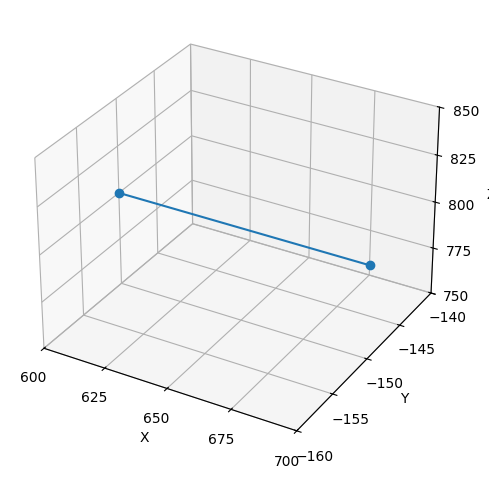

In [8]:
plot_poses(poses)

In [9]:
joints = [robot.ik(p, q=start_end_joints[0]) for p in poses]

mid_joints = np.mean(joints, axis=0)
mid_pose = robot.fk(mid_joints)

deviated_poses = np.insert(arr=poses, obj=1, values=mid_pose, axis=0)



In [10]:


# split linear trajectory in half, creating two joint-space segments
mid_cartesian_point = np.mean([poses[1, :-1, -1], poses[0, :-1, -1]], axis=0)

mid_pose = poses[0].copy()
mid_pose[:-1, -1] = mid_cartesian_point

segmented_poses = np.insert(arr=poses, obj=1, values=mid_pose, axis=0)



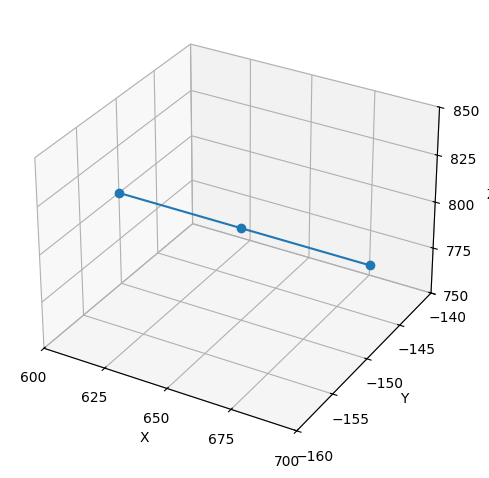

In [11]:
plot_poses(segmented_poses)



In [12]:
joints = [robot.ik(p, q=start_end_joints[0]) for p in segmented_poses]

# compute deviation for first segment
mid_joints = np.mean(joints[:2], axis=0)
first_mid_pose = robot.fk(mid_joints)
first_segmented_poses = np.insert(arr=poses,
                                  obj=1,
                                  values=first_mid_pose,
                                  axis=0)
compute_deviation(first_segmented_poses)

# compute deviation for second segment
mid_joints = np.mean(joints[1:], axis=0)
second_mid_pose = robot.fk(mid_joints)
second_segmented_poses = np.insert(arr=poses,
                                   obj=1,
                                   values=second_mid_pose,
                                   axis=0)
compute_deviation(second_segmented_poses)



Deviation: 2.04609mm
Deviation: 0.72488mm
